ARTI308 - Machine Learning

## Lab 4: Data Quality Assessment & Preprocessing

 Import Libraries

In [140]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1.Load Dataset

In [141]:
df = pd.read_csv("titanic.csv")

In [142]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 2. Data Quality Assessment

In [143]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [144]:
df.dtypes

,0
PassengerId,int64
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64


In [145]:
# Convert columns to numeric if needed
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')
df['Fare'] = pd.to_numeric(df['Fare'], errors='coerce')

In [146]:
df.dtypes

,0
PassengerId,int64
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64


## 3. Handling Missing Values

In [147]:
df.isna()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,False,False,False,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,True,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
886,False,False,False,False,False,False,False,False,False,False,True,False
887,False,False,False,False,False,False,False,False,False,False,False,False
888,False,False,False,False,False,True,False,False,False,False,True,False
889,False,False,False,False,False,False,False,False,False,False,False,False


In [148]:
df.isna().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


The dataset contains missing values in Age, Cabin, and Embarked.
Cabin has many missing values, while Age has some missing values.
The dataset also includes both numerical and categorical features.

Introduce Artificial Missing Values

In [149]:
df2 = df.copy()
df2.loc[0:5, 'Age'] = np.nan

In [150]:
df2.isna().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,182
SibSp,0
Parch,0
Ticket,0
Fare,0


In [151]:
df2.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,NaN,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,NaN,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,NaN,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,NaN,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,NaN,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


Strategy 1: Remove Records

In [152]:
df_remove = df2.dropna()

In [153]:
print('df with NaN: ', df2.shape)
print('df without NaN: ', df_remove.shape)

df with NaN:  (891, 12)
df without NaN:  (181, 12)


In [154]:
df_remove.isna().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


Strategy 2: Mean Imputation

In [155]:
df_mean = df2.copy()
df_mean['Age'] = df_mean['Age'].fillna(df_mean['Age'].mean())

In [156]:
df_mean.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,29.688533,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,29.688533,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,29.688533,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,29.688533,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,29.688533,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,29.688533,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.000000,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.000000,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.000000,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.000000,1,0,237736,30.0708,NaN,C


Strategy 3: Median Imputation

In [157]:
df_median = df2.copy()
df_median['Age'] = df_median['Age'].fillna(df_median['Age'].median())

In [158]:
df_median.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,28.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,28.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,28.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,28.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,28.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,28.0,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


The median strategy was selected to handle missing values in the Age column.
Median is preferred because it is less affected by outliers than the mean.
This makes it a more reliable method for numerical data such as Age.

## 4. Handling Outliers

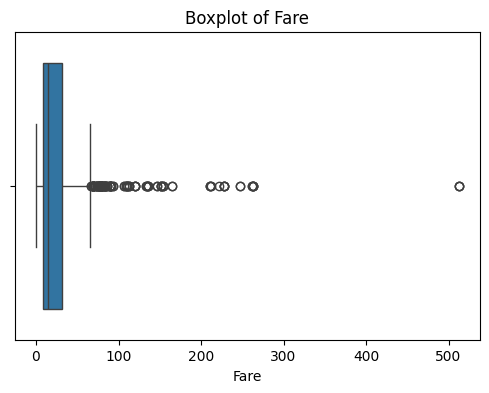

In [159]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['Fare'])
plt.title('Boxplot of Fare')
plt.show()

Detect Outliers using IQR

In [160]:
Q1 = df['Fare'].quantile(0.25)
Q3 = df['Fare'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['Fare'] < lower) | (df['Fare'] > upper)]
outliers.head(15)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
27,28,0,1,"Fortune, Mr. Charles Alexander",male,19.0,3,2,19950,263.0000,C23 C25 C27,S
31,32,1,1,"Spencer, Mrs. William Augustus (Marie Eugenie)",female,NaN,1,0,PC 17569,146.5208,B78,C
34,35,0,1,"Meyer, Mr. Edgar Joseph",male,28.0,1,0,PC 17604,82.1708,NaN,C
52,53,1,1,"Harper, Mrs. Henry Sleeper (Myna Haxtun)",female,49.0,1,0,PC 17572,76.7292,D33,C
61,62,1,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0000,B28,NaN
62,63,0,1,"Harris, Mr. Henry Birkhardt",male,45.0,1,0,36973,83.4750,C83,S
72,73,0,2,"Hood, Mr. Ambrose Jr",male,21.0,0,0,S.O.C. 14879,73.5000,NaN,S
88,89,1,1,"Fortune, Miss. Mabel Helen",female,23.0,3,2,19950,263.0000,C23 C25 C27,S
102,103,0,1,"White, Mr. Richard Frasar",male,21.0,0,1,35281,77.2875,D26,S


Remove Outliers

In [161]:
df_no_outliers = df[(df['Fare'] >= lower) & (df['Fare'] <= upper)]

In [162]:
print('df with outliers: ', df.shape)
print('df without outliers: ', df_no_outliers.shape)

df with outliers:  (891, 12)
df without outliers:  (775, 12)


Outliers were detected in the Fare column using the IQR method.
Values outside the acceptable range were considered outliers.
These outliers were removed to improve the quality of the dataset.

Capping Outliers

In [163]:
lower_cap = df['Fare'].quantile(0.05)   # 5%
upper_cap = df['Fare'].quantile(0.95)   # 95%

df_capped = df.copy()
df_capped['Fare'] = df_capped['Fare'].clip(lower_cap, upper_cap)

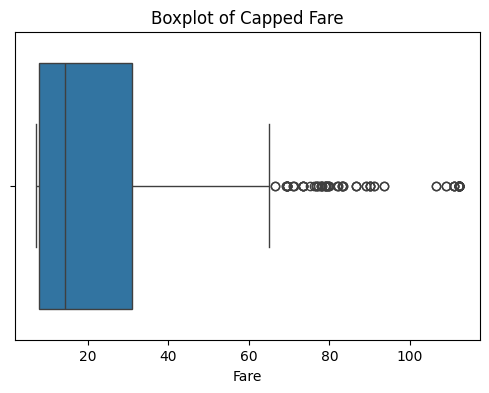

In [164]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df_capped['Fare'])
plt.title('Boxplot of Capped Fare')
plt.show()

## 5. Data Transformation – Normalization

In [165]:
df_norm = df[['Age', 'Fare']].copy()
df_norm['Age'] = df_norm['Age'].fillna(df_norm['Age'].median())
df_norm['Fare'] = df_norm['Fare'].fillna(df_norm['Fare'].median())

df_norm.head()

,Age,Fare
0,22.0,7.2500
1,38.0,71.2833
2,26.0,7.9250
3,35.0,53.1000
4,35.0,8.0500


Min-Max Normalization

In [166]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df_scaled = df_norm.copy()

df_scaled[['Age', 'Fare']] = scaler.fit_transform(df_scaled[['Age', 'Fare']])

df_scaled.head()

,Age,Fare
0,0.271174,0.014151
1,0.472229,0.139136
2,0.321438,0.015469
3,0.434531,0.103644
4,0.434531,0.015713


Z-Score Normalization

In [167]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_standardized = df_norm.copy()

df_standardized[['Age', 'Fare']] = scaler.fit_transform(df_standardized[['Age', 'Fare']])

df_standardized.head()

,Age,Fare
0,-0.565736,-0.502445
1,0.663861,0.786845
2,-0.258337,-0.488854
3,0.433312,0.420730
4,0.433312,-0.486337


Min-Max normalization scales values between 0 and 1.
Z-score normalization standardizes the data using the mean and standard deviation.
Both methods were applied to the numerical features Age and Fare.

## 6. Data Reduction – Principal Component Analysis (PCA)

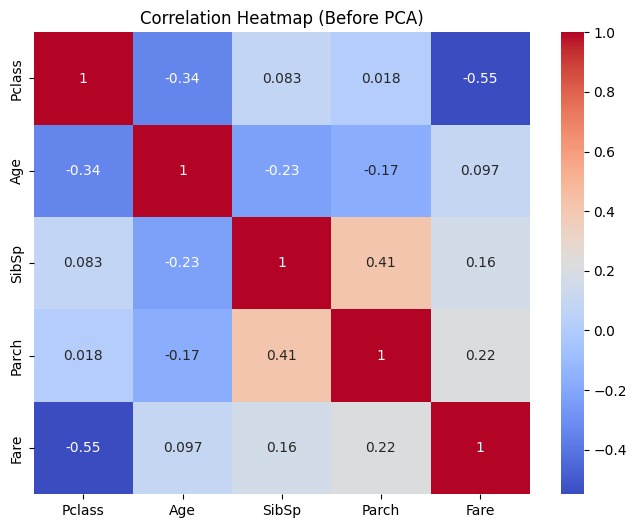

In [168]:
df_pca = df[['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']].copy()

df_pca['Age'] = df_pca['Age'].fillna(df_pca['Age'].median())
df_pca['Fare'] = df_pca['Fare'].fillna(df_pca['Fare'].median())

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_standardized = pd.DataFrame(
    scaler.fit_transform(df_pca),
    columns=df_pca.columns
)

plt.figure(figsize=(8,6))
sns.heatmap(df_standardized.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap (Before PCA)")
plt.show()

In [169]:
correlation = df_standardized.corr()
correlation

,Pclass,Age,SibSp,Parch,Fare
Pclass,1.000000,-0.339898,0.083081,0.018443,-0.549500
Age,-0.339898,1.000000,-0.233296,-0.172482,0.096688
SibSp,0.083081,-0.233296,1.000000,0.414838,0.159651
Parch,0.018443,-0.172482,0.414838,1.000000,0.216225
Fare,-0.549500,0.096688,0.159651,0.216225,1.000000


PCA

In [170]:
from sklearn.decomposition import PCA

X = df_standardized

pca = PCA(n_components=2)
principal_components = pca.fit_transform(X)

print("Explained Variance Ratio:", pca.explained_variance_ratio_)

Explained Variance Ratio: [0.33960812 0.32520788]


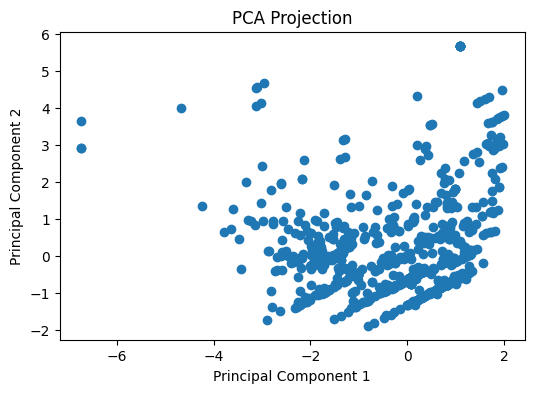

In [171]:
plt.figure(figsize=(6,4))
plt.scatter(principal_components[:,0], principal_components[:,1])
plt.title("PCA Projection")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

To make the correlation analysis more meaningful, more numerical features were included: Pclass, Age, SibSp, Parch, and Fare. This produced a larger heatmap and made PCA more appropriate for dimensionality reduction.

Final Summary for the Assignment

In [172]:
print("Dataset shape:", df.shape)
print("\nMissing values:\n", df.isna().sum())
print("\nSummary statistics:\n", df.describe())

Dataset shape: (891, 12)

Missing values:
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Summary statistics:
        PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  

In this lab, data quality issues were identified in the Titanic dataset.
Missing values were handled using the median strategy for the Age column.
Outliers were detected and handled using the IQR method on the Fare column.
Numerical features were normalized using both Min-Max and Z-score methods.
Finally, PCA was applied after checking the correlation between numerical features.